## 4. Exploratory Data Analysis (2023 - 2026)

The EDA is developed as follows:
1. Descriptive statistics
2. Univariate analysis (distribution shape)
3. Temporal behavior - Time series analysis
4. Relationships analysis

In [1]:
# import libraries
import pandas as pd
from pathlib import Path
import warnings

# filter User and Filter Warnings for privacy matters
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# define clean dataset folder path
clean_dataset_path = Path('../dataset/clean/updated')

# read merge-dataset
data = pd.read_csv(clean_dataset_path / 'merged-dataset.csv')

In [2]:
# filter dataset by date
data = data[
    (data['Date'] >= '2023-05-01 00:00:00')
    &
    (data['Date'] < '2026-06-01 00:00:00')
] 
data

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
2878,2023-05-01 00:00:00,114.35000,0.63,2.50,0.00,2.448,8.63,1.42,13.18,0.345220,22409.25050,23168.75000
2879,2023-05-01 01:00:00,112.00000,0.63,2.40,0.00,2.318,7.49,1.41,11.93,0.372171,20911.74975,21754.50000
2880,2023-05-01 02:00:00,110.00000,0.63,2.35,0.00,2.209,7.09,1.43,11.50,0.383478,20022.24975,21118.00000
2881,2023-05-01 03:00:00,106.75000,0.63,2.37,0.00,2.147,6.85,1.52,11.37,0.397537,19595.00000,20621.75075
2882,2023-05-01 04:00:00,108.98000,0.63,2.40,0.00,2.138,6.82,1.61,11.46,0.404887,19424.00050,20515.00025
...,...,...,...,...,...,...,...,...,...,...,...,...
29867,2026-05-31 19:00:00,152.93646,0.60,6.98,1.44,2.244,12.71,2.31,24.04,0.471298,32567.75025,31232.99950
29868,2026-05-31 20:00:00,162.48019,0.60,8.46,0.11,1.864,13.14,2.09,24.40,0.461475,32957.50000,32526.00000
29869,2026-05-31 21:00:00,161.37194,0.60,8.78,0.00,1.784,13.40,1.93,24.71,0.457709,32685.74975,32675.74950
29870,2026-05-31 22:00:00,158.47406,0.60,7.13,0.00,1.600,13.72,1.87,23.32,0.411664,30581.49950,30908.00025


In [3]:
data

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
2878,2023-05-01 00:00:00,114.35000,0.63,2.50,0.00,2.448,8.63,1.42,13.18,0.345220,22409.25050,23168.75000
2879,2023-05-01 01:00:00,112.00000,0.63,2.40,0.00,2.318,7.49,1.41,11.93,0.372171,20911.74975,21754.50000
2880,2023-05-01 02:00:00,110.00000,0.63,2.35,0.00,2.209,7.09,1.43,11.50,0.383478,20022.24975,21118.00000
2881,2023-05-01 03:00:00,106.75000,0.63,2.37,0.00,2.147,6.85,1.52,11.37,0.397537,19595.00000,20621.75075
2882,2023-05-01 04:00:00,108.98000,0.63,2.40,0.00,2.138,6.82,1.61,11.46,0.404887,19424.00050,20515.00025
...,...,...,...,...,...,...,...,...,...,...,...,...
29867,2026-05-31 19:00:00,152.93646,0.60,6.98,1.44,2.244,12.71,2.31,24.04,0.471298,32567.75025,31232.99950
29868,2026-05-31 20:00:00,162.48019,0.60,8.46,0.11,1.864,13.14,2.09,24.40,0.461475,32957.50000,32526.00000
29869,2026-05-31 21:00:00,161.37194,0.60,8.78,0.00,1.784,13.40,1.93,24.71,0.457709,32685.74975,32675.74950
29870,2026-05-31 22:00:00,158.47406,0.60,7.13,0.00,1.600,13.72,1.87,23.32,0.411664,30581.49950,30908.00025


### 4.1. Descriptive Statistics

Descriptive statistics includes measures of central tendency, dispersion and distribution shape through the five years time span.

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26994 entries, 2878 to 29871
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               26994 non-null  str    
 1   Prices             26994 non-null  float64
 2   Geothermal         26994 non-null  float64
 3   Hydro              26994 non-null  float64
 4   Photovoltaic       26994 non-null  float64
 5   Self-consumption   26994 non-null  float64
 6   Thermal            26994 non-null  float64
 7   Wind               26994 non-null  float64
 8   TOT Generation     26994 non-null  float64
 9   Renewables weight  26994 non-null  float64
 10  Total Load         26994 non-null  float64
 11  Load forecasted    26994 non-null  float64
dtypes: float64(11), str(1)
memory usage: 2.5 MB


In [5]:
# fix Date datatype
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data = data.dropna(subset=['Date'])
data = data.sort_values('Date').reset_index(drop=True)

In [6]:
data

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
0,2023-05-01 00:00:00,114.35000,0.63,2.50,0.00,2.448,8.63,1.42,13.18,0.345220,22409.25050,23168.75000
1,2023-05-01 01:00:00,112.00000,0.63,2.40,0.00,2.318,7.49,1.41,11.93,0.372171,20911.74975,21754.50000
2,2023-05-01 02:00:00,110.00000,0.63,2.35,0.00,2.209,7.09,1.43,11.50,0.383478,20022.24975,21118.00000
3,2023-05-01 03:00:00,106.75000,0.63,2.37,0.00,2.147,6.85,1.52,11.37,0.397537,19595.00000,20621.75075
4,2023-05-01 04:00:00,108.98000,0.63,2.40,0.00,2.138,6.82,1.61,11.46,0.404887,19424.00050,20515.00025
...,...,...,...,...,...,...,...,...,...,...,...,...
26989,2026-05-31 19:00:00,152.93646,0.60,6.98,1.44,2.244,12.71,2.31,24.04,0.471298,32567.75025,31232.99950
26990,2026-05-31 20:00:00,162.48019,0.60,8.46,0.11,1.864,13.14,2.09,24.40,0.461475,32957.50000,32526.00000
26991,2026-05-31 21:00:00,161.37194,0.60,8.78,0.00,1.784,13.40,1.93,24.71,0.457709,32685.74975,32675.74950
26992,2026-05-31 22:00:00,158.47406,0.60,7.13,0.00,1.600,13.72,1.87,23.32,0.411664,30581.49950,30908.00025


In [7]:
data.describe()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
count,26994,26994.000000,26994.000000,26994.000000,26994.000000,26994.000000,26994.000000,26994.000000,26994.000000,26994.000000,26994.000000,26994.000000
mean,2024-11-13 16:34:22.458324,114.703302,0.600536,5.188528,3.428962,3.773063,14.448925,2.573349,26.240300,0.449635,35356.258417,35544.105398
min,2023-05-01 00:00:00,0.000000,0.470000,1.240000,0.000000,0.028000,3.990000,0.050000,11.110000,0.105882,17546.750000,17504.249500
25%,2024-02-06 04:15:00,98.970000,0.600000,3.310000,0.000000,2.375250,9.880000,1.022500,20.550000,0.330199,28397.500000,28621.812438
50%,2024-11-13 10:30:00,113.254855,0.600000,4.820000,0.140000,3.473000,13.630000,2.080000,25.940000,0.432408,34783.374875,34909.000375
75%,2025-08-21 16:45:00,131.780285,0.610000,6.790000,6.460000,4.847750,18.260000,3.770000,31.440000,0.553861,42055.437625,42286.374188
max,2026-05-31 23:00:00,289.000000,0.640000,13.890000,19.370000,11.357000,35.500000,9.020000,48.430000,0.849329,58528.250000,59726.499750
std,NaN,30.565578,0.018661,2.315527,4.780874,1.766010,5.867302,1.889114,6.885118,0.156512,8084.695614,8061.455828


Comparing these descriptive statistics with the previous ones, we can say that the average spot power prices in Italy structurally decreased, from 156.20 €/MWh of the period 2021-2025, to 114.70 €/MWh in the period 2023-2026.  
This is consistent with the gas shock due to the Russia-Ukraine war, that highly affected the Italian energy market which is strongly influenced by natural gas prices, which still represent the dominant energy source, as also shown by the Thermal column, which reports the highest average electricity generation among all sources.  
Also, the average power production through hydro, photovoltaic drecreased, while wind, geothermal and thermal average production increased.  
The actual Load and the forecasted Load display similar patterns across key descriptive statistics, suggesting a good overall alignment between observed and predicted energy consumption levels, although a more detailed error analysis would be required to fully assess predictive performance.

In [8]:
cols = ['Prices', 'Total Load', 'TOT Generation']

summary = []

for col in cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    std = data[col].std()
    mean = data[col].mean()

    summary.append({
        'variable': col,
        'mean': data[col].mean(),
        'median': data[col].median(),
        'min': data[col].min(),
        'max': data[col].max(),
        'Q1': q1,
        'Q3': q3,
        'std': std,
        'variance': data[col].var(),
        'range': data[col].max() - data[col].min(),
        'IQR': iqr,
        'RSD': std / mean
    })

summary_df = pd.DataFrame(summary)
summary_df

,variable,mean,median,min,max,Q1,Q3,std,variance,range,IQR,RSD
0,Prices,114.703302,113.254855,0.00,289.00,98.97,131.780285,30.565578,9.342545e+02,289.00,32.810285,0.266475
1,Total Load,35356.258417,34783.374875,17546.75,58528.25,28397.50,42055.437625,8084.695614,6.536230e+07,40981.50,13657.937625,0.228664
2,TOT Generation,26.240300,25.940000,11.11,48.43,20.55,31.440000,6.885118,4.740485e+01,37.32,10.890000,0.262387


By the summary of sttistics, the prices demonsrated a decrese of volatility, shown in both Standard Deviation (from 104.71 to 30.56) and Variance (from 1.096515e+04 to 9.342545e+02).

Generation still displays higher variability, which is consistent with the structure of the national energy mix. Renewable energy sources, mainly solar and wind, keep increase their share and are inherently subject to weather-related fluctuations.

### 4.2. Univariate analysis

In [9]:
dist_summary = []

for col in cols:
    skewness = data[col].skew()
    kurtosis = data[col].kurt()

    dist_summary.append({
        'variable': col,
        'skewness': skewness,
        'kurtosis': kurtosis,
    })

dist_summary_df = pd.DataFrame(dist_summary)
dist_summary_df

,variable,skewness,kurtosis
0,Prices,-0.161470,2.121404
1,Total Load,0.163794,-0.954556
2,TOT Generation,0.213851,-0.763905


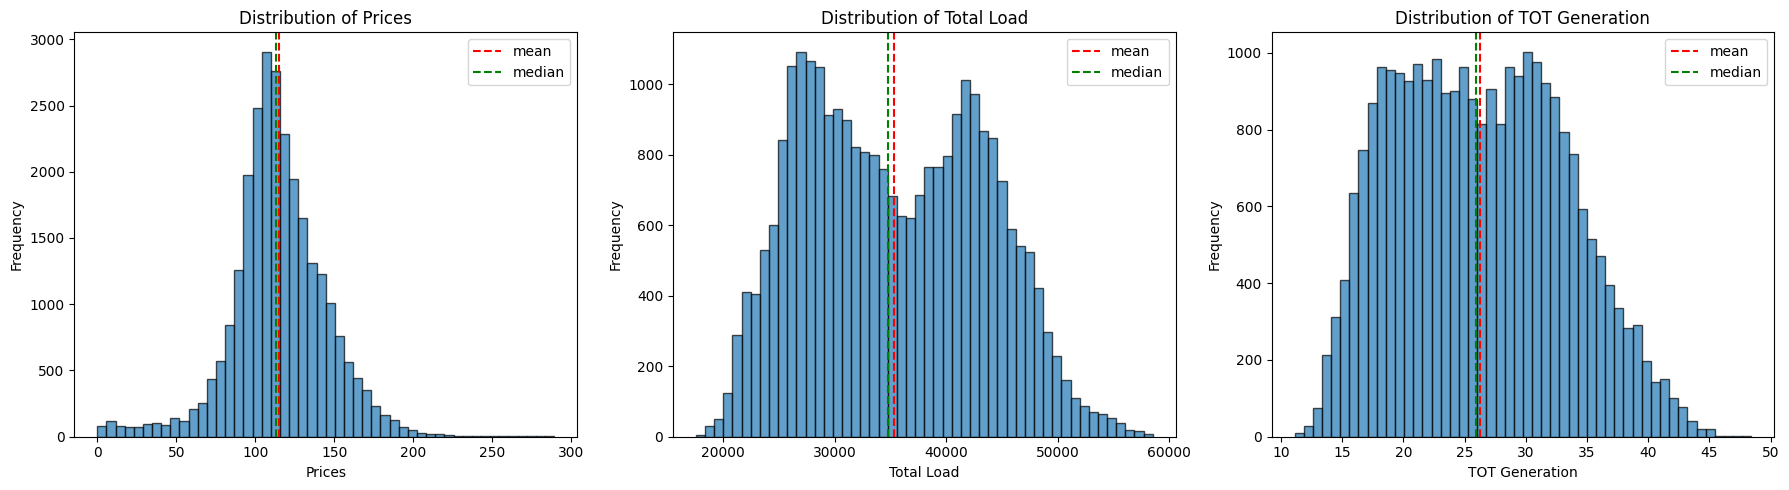

In [10]:
import matplotlib.pyplot as plt

# columns title
cols = ['Prices', 'Total Load', 'TOT Generation']

#create plot
fig, axes = plt.subplots(1, len(cols), figsize=(18, 5))

for i, col in enumerate(cols):
    axes[i].hist(data[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(data[col].mean(), color='red', linestyle='--', label='mean')
    axes[i].axvline(data[col].median(), color='green', linestyle='--', label='median')
    axes[i].legend()

plt.tight_layout()
plt.show()

From these results, we can notice that the prices distribution is more symetric than in previous analysis, as the mean and median are almost the same. The shape too is normal-like, even though skewness and kurtosis don't confirm Normal distribution.  
Load and Generation are almost symetric and negative kurtosis indicates that these two are stable variables.

### 4.3. Time series analysis

In this section, Prices, Load and Generation relationship will be investigated. Time series evolution of those variables are shown during the selected time span.

#### 4.3.1. Raw time series

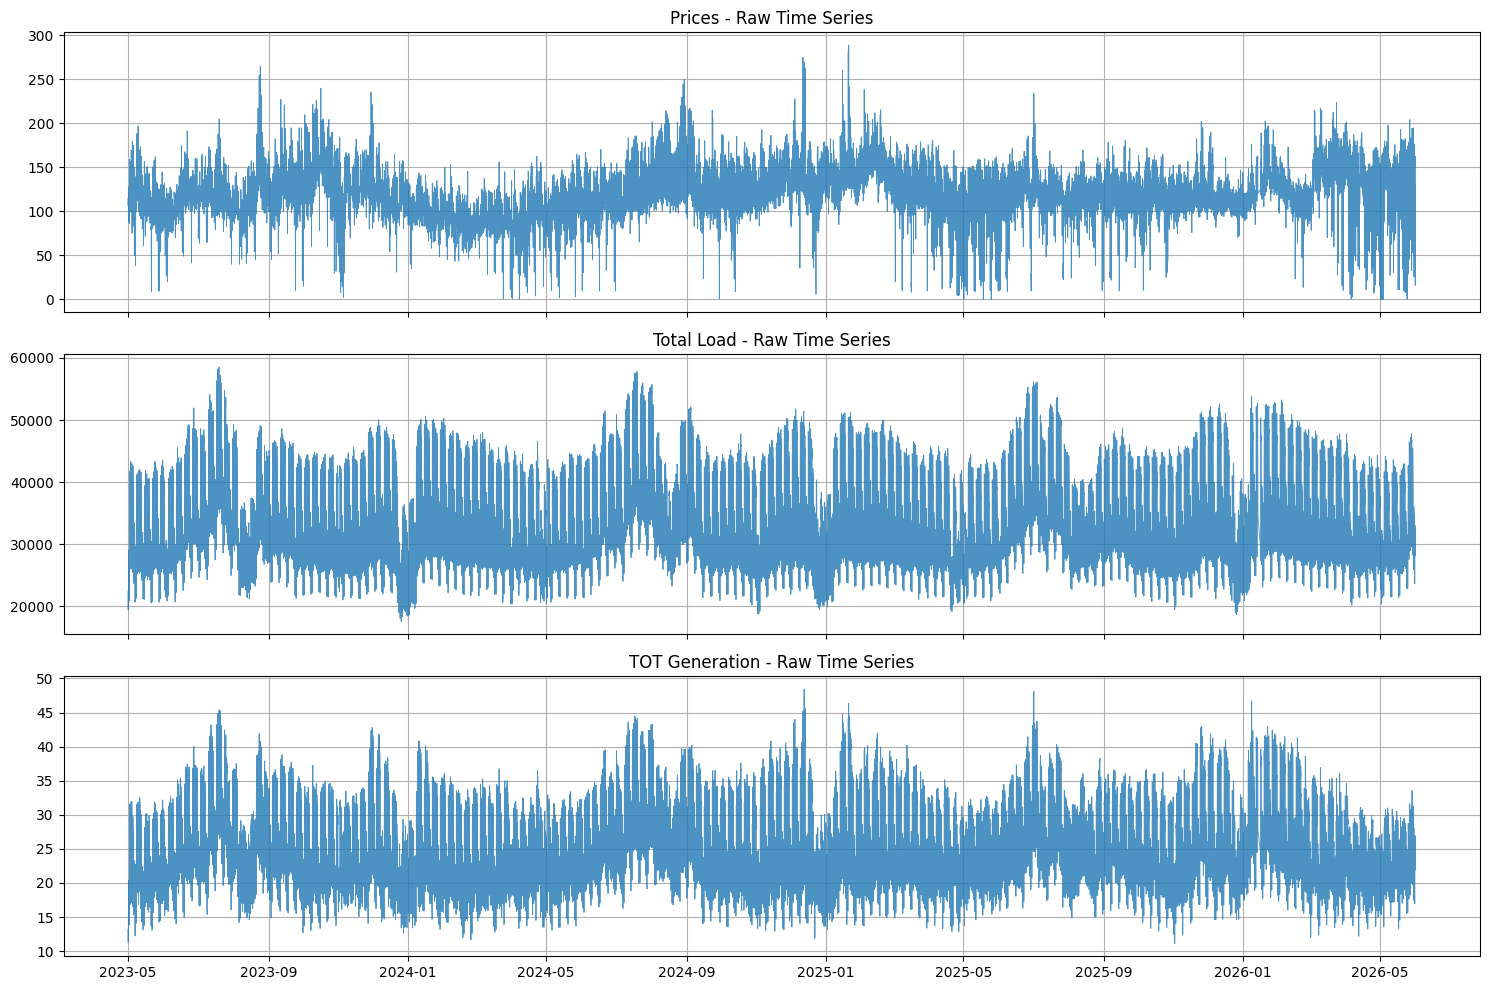

In [11]:
# import library
import matplotlib.pyplot as plt

# columns name
cols = ['Prices', 'Total Load', 'TOT Generation']

# plot graph
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col], linewidth=0.6, alpha=0.8)
    ax[i].set_title(f'{col} - Raw Time Series')
    ax[i].grid(True)

plt.tight_layout()
plt.show()

From this graph, electricity prices seem to be at normal level again after 2022 geopolitical shock. However it is noticeable how frequent lower prices became in srping 2025 and 2026.  
Load and generation still show stability and high correlation beyween the two of them.

#### 4.3.2. Rolling mean

For excluding the noise from the hourly observations and avoiding high copmutational effotrs, a rolling mean on the previous 24 hours is calculated and displayed.

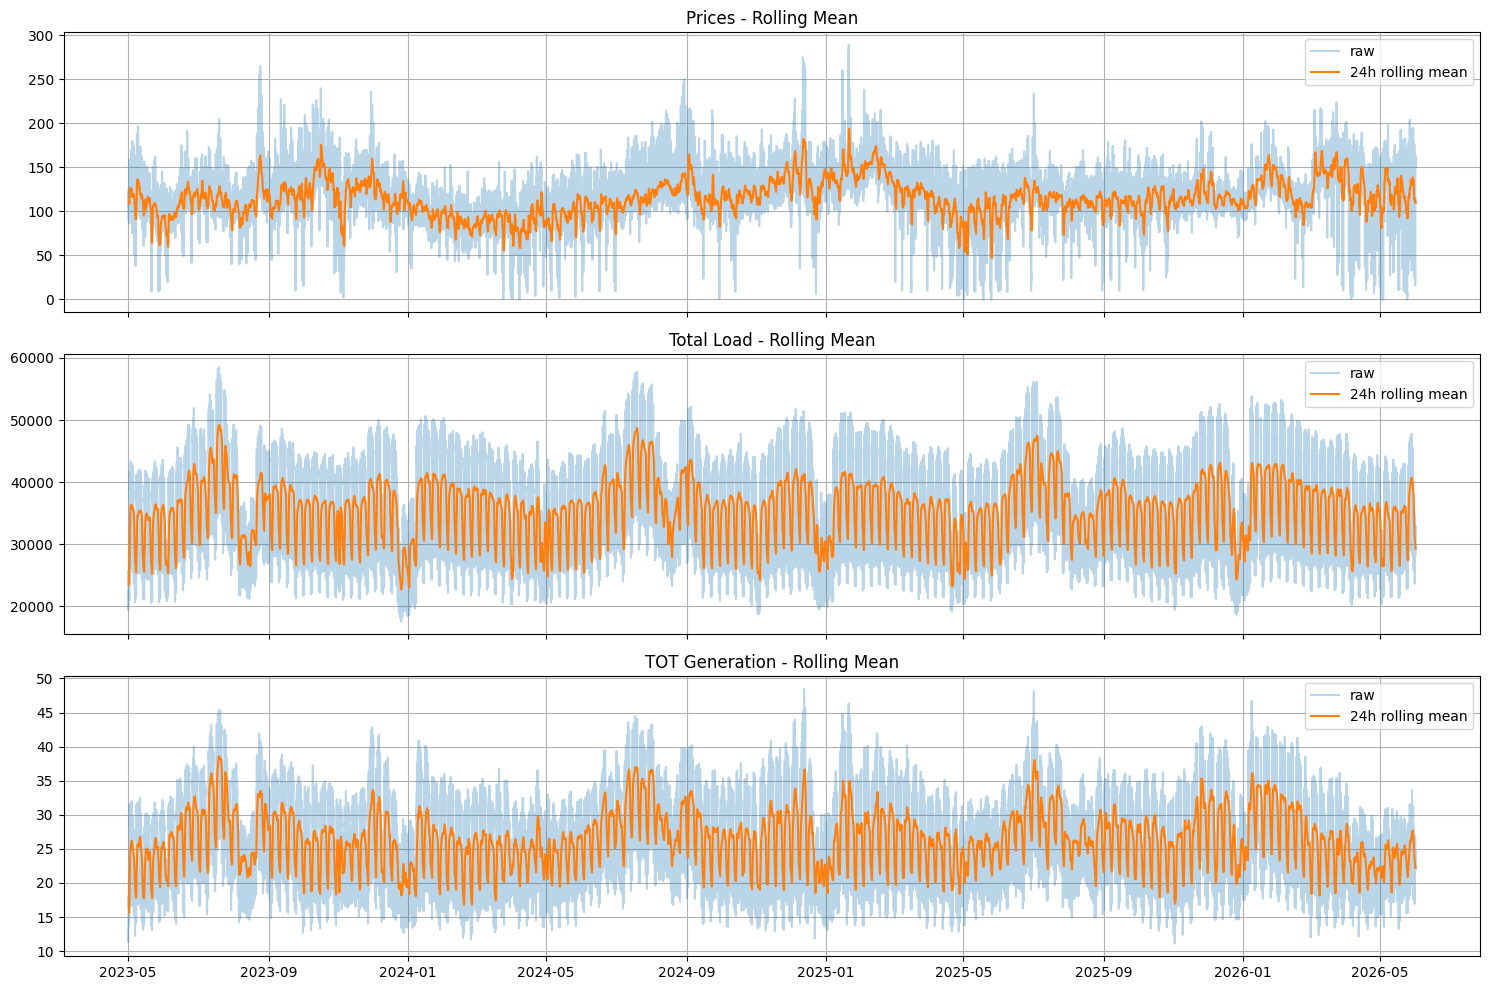

In [12]:
# define rolling window
window = 24  # 24h rolling window (1 day)

fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col], alpha=0.3, label='raw')
    ax[i].plot(data['Date'], data[col].rolling(window).mean(), label='24h rolling mean')
    ax[i].set_title(f'{col} - Rolling Mean')
    ax[i].legend()
    ax[i].grid(True)

plt.tight_layout()
plt.show()

It is evident from the first graph of the rolling average **Prices** are constant on long term, despite numerous variablities are displayed. Prices volatility is a nowadays discussed issue, due to renewables penetration and solar cannibalization, which renewable source affect the availability of production and so the marginal prices in power spot markets.  

Yearly Italian **Load** shows a dual-season pattern, typical of temperate-climate electricity systems, since in winter heating are needed and diffused while in summer cooling systems are needed.  
It is noticeable how in spring and autumn months there is less demand of energy, while a particular New-Years-Eve effect is observable, characterized by a yearly minimum load of energy. This could be related to Christmas, New Year's Eve and Epiphany holidays, in which often Italian tend to organize vacations abroad, while all commercial buildings are closed.

The **Generation** pattern seems to follow an yearly cycle, similar to the Load one.

#### 4.3.3. Volatility Analysis

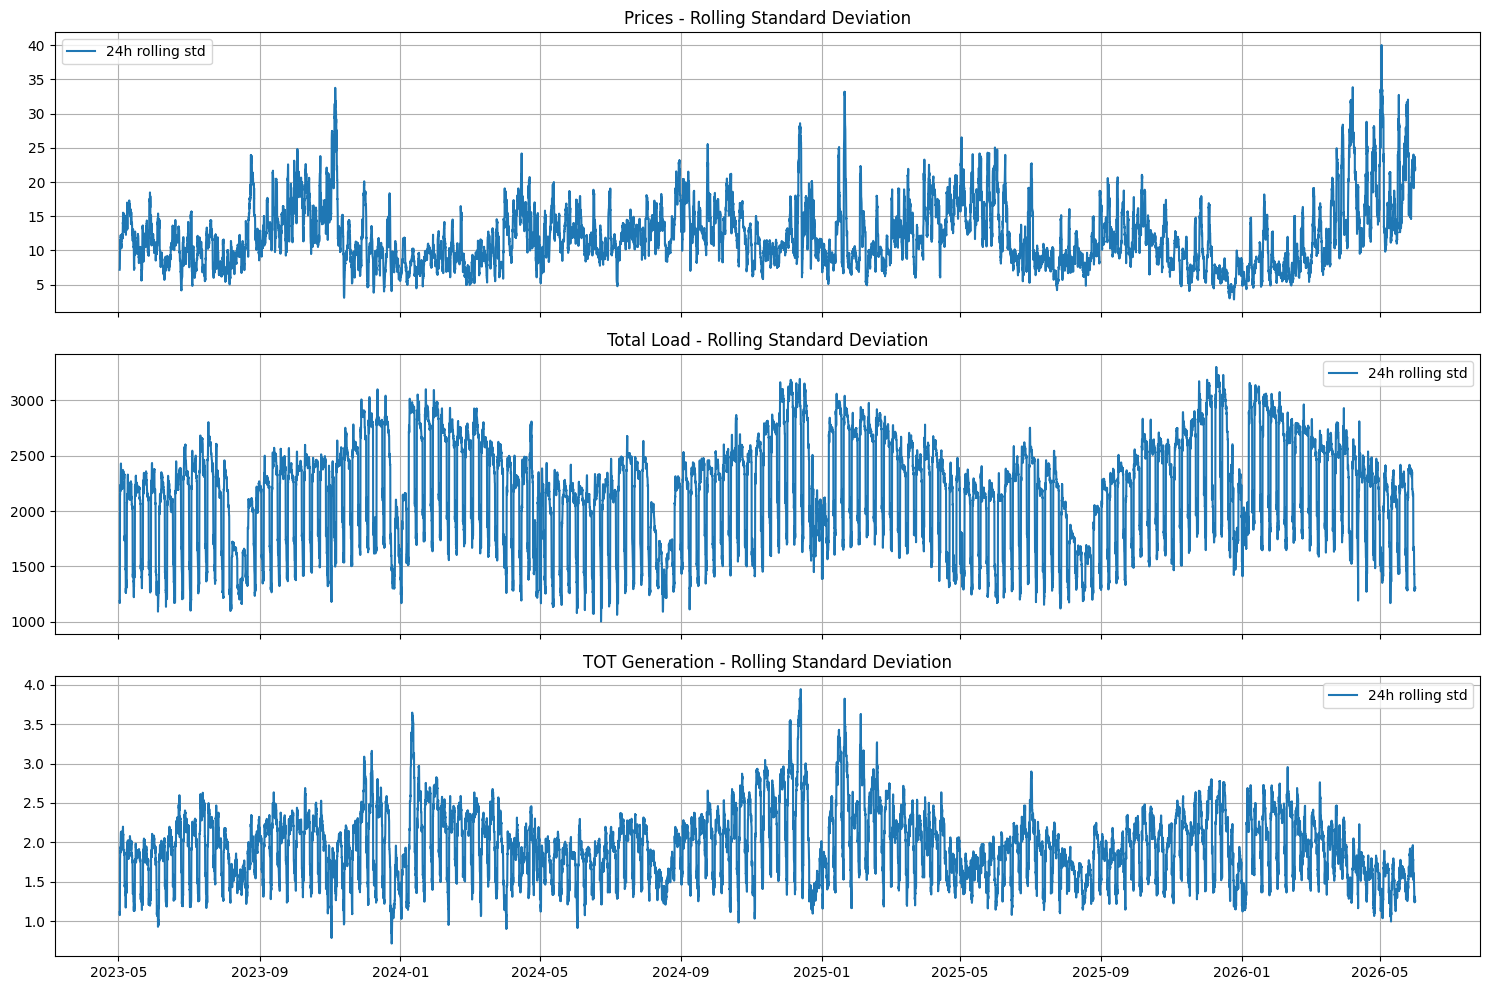

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col].diff().rolling(window).std(), label='24h rolling std')
    ax[i].set_title(f'{col} - Rolling Standard Deviation')
    ax[i].legend()
    ax[i].grid(True)

plt.tight_layout()
plt.show()

The **prices** rolling standard deviation on 24 hours rolling window graph shows an interesting trend in the first semester of 2026 which is the highest and most durable volatility in Italian PUN price.  
This is consistent with latest climate impact on whole Europe and solar and wind diffusion as main renewable energy sources.  
Another consideration that is evident, is that prices rolling standard deviation trend is specular to load and generation ones.  

**Generation** and **Load** have a similar pattern to the rolling mean graphs, which is explainadble by less volatility bounded by notable physical constraints.


#### 4.3.4. Intraday preview

Intraday pattern of 2023-2026 shows a lower "duck-shape" curve, which has the same shape of the previous analysis, but lower average values.

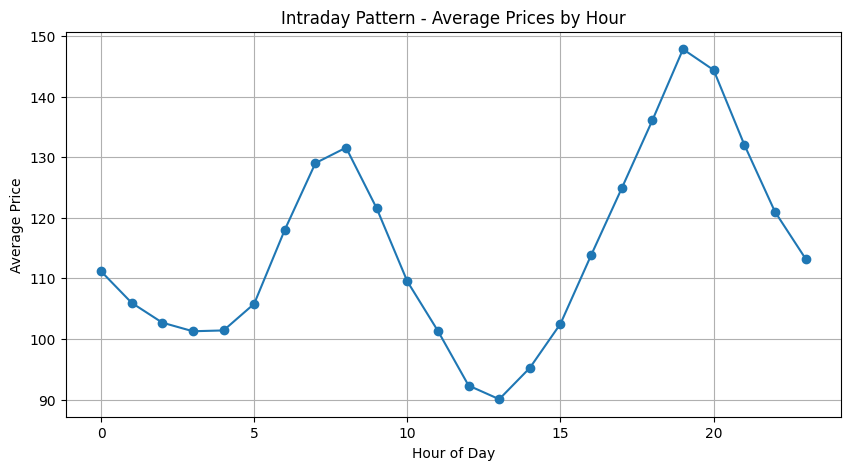

In [14]:
# select hours
data['hour'] = data['Date'].dt.hour

# group hours and calculate average prices
hourly_pattern = data.groupby('hour')['Prices'].mean()

# display graph
plt.figure(figsize=(10,5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('Intraday Pattern - Average Prices by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

### 4.4. Relationship analysis
Supply-demand interaction is crucial for determining the power spot markets prices determination.

#### 4.4.1. Correlation matrix

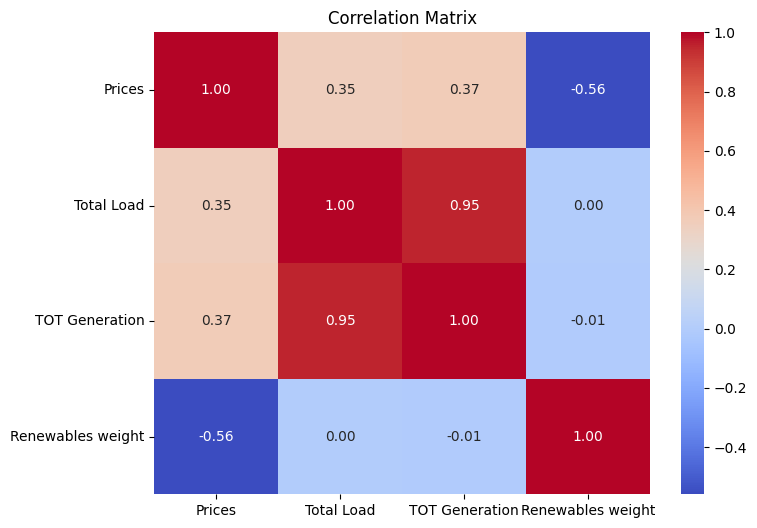

In [15]:
# inmport libraries
import matplotlib.pyplot as plt
import seaborn as sns

# select columns of interest
cols = [
    'Prices',
    'Total Load',
    'TOT Generation',
    'Renewables weight'
]

# correlation matrix
corr_matrix = data[cols].corr()

# display heated matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

Introducing the **renewable share** in the Italian generation mix, a moderate negative correlation with electricity prices (-0.56) emerges, indicating that higher renewable penetration is associated with lower spot electricity prices, consistent with the merit-order effect. Compared with the previous analysis, the magnitude of the negative correlation increased from -0.39 to -0.56, suggesting that, in the post-2022 market regime, renewable penetration is more strongly associated with electricity prices than in the earlier period.

The correlation between renewable share and load is close to zero, suggesting little or no linear relationship between the two variables. A similar result is observed for renewable share and total generation (-0.01), despite total generation being highly correlated with load (0.96). The correlations between electricity prices and both load (0.35) and total generation (0.37) are stronger than in the previous analysis, where both coefficients were approximately 0.27. This suggests that demand and generation conditions became more closely associated with electricity prices during the post-2022 period.

Overall, these findings are consistent with the regression results, supporting the hypothesis that the renewable share has become increasingly important in explaining spot electricity prices. Finally, total generation (supply) and load (a proxy for demand) exhibit a moderate positive correlation (0.29), indicating only partial coupling between electricity demand and domestic production. This is consistent with the role of electricity imports and the structure of the Italian electricity market, which prevent a one-to-one correspondence between domestic demand and generation.


#### 4.4.2. Scatterplots

A. Prices drivers
* Prices vs Total Load
* Prices vs TOT Generation
* Prices vs Renewables weight

B. Supply structure
* Total Load vs TOT Generation
* Total Load vs Renewables weight
* TOT Generation vs Renewables weight

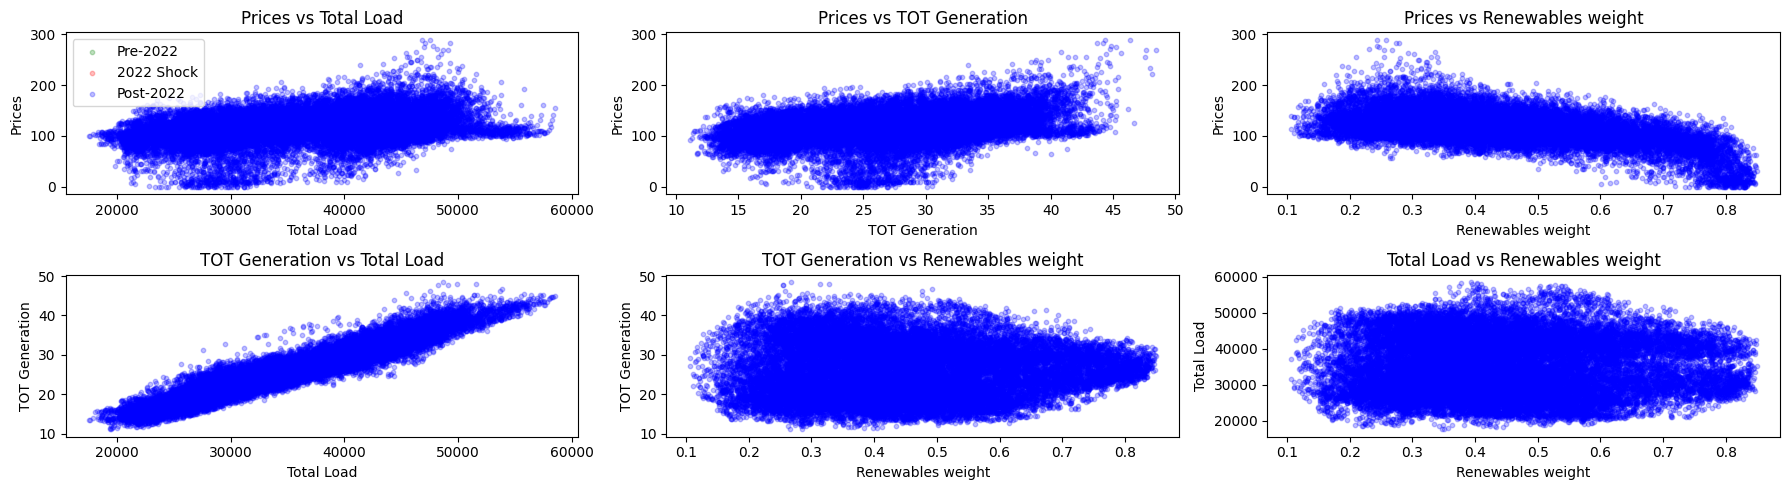

In [ ]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

# define pair of variables to compare
scatter_pairs = [
    ('Total Load', 'Prices'),
    ('TOT Generation', 'Prices'),
    ('Renewables weight', 'Prices'),
    ('Total Load', 'TOT Generation'),
    ('Renewables weight', 'TOT Generation'),
    ('Renewables weight', 'Total Load')
]

# define colors for each market regime
colors = {
    'Post-2022': 'blue'
}

# display graphs
fig, axes = plt.subplots(2, 3, figsize=(18, 5))
axes = axes.flatten()

for i, (x, y) in enumerate(scatter_pairs):
    for regime, color in colors.items():
        subset = data[data['Regime'] == regime]
        axes[i].scatter(subset[x], subset[y],
                        alpha=0.25, s=10,
                        color=color,
                        label=regime)

    axes[i].set_title(f'{y} vs {x}')
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

axes[0].legend()
plt.tight_layout()
plt.show()

## Conclusions of the preliminary Exploratory data analysis

The exploratory analysis highlights structural changes in previous analysis.
While demand remains relatively stable, prices still exhibit high volatility despite normal-like distribution. Also, among the findings, the higher magnitude in correlation between PUN and generation by renewables source indicates that renewable penetration plays a relevant role, even more than earlier, in moderating price levels, motivating a dedicated analysis of its impact on price formation.